# Project 1: Automated Market Trend Data Generation

In [15]:
import pandas as pd
import numpy as np

# Superior Approach: Vectorized Data Generation
def generate_market_data(n_rows=10000):
    dates = pd.date_range("2025-01-01", periods=n_rows, freq="h")
    # Generate prices using a random walk
    price_changes = np.random.normal(0, 1, n_rows)
    prices = 100 + np.cumsum(price_changes)

    df = pd.DataFrame({
    'timestamp': dates,
    'price': prices,
    'volume': np.random.randint(100, 1000, n_rows),
    'catagory': np.random.choice(['Tech', 'Energy', 'Retail', 'Health'], n_rows)
    })

    # INDENT THESE LINES: Now 'df' is recognized within the function scope
    df.iloc[np.random.randint(0, n_rows, 50), 1] = np.nan
    return df

# Now you call the function to actually create the object in your workspace
market_df = generate_market_data()
       

    

In [16]:
market_df

# See the first 5 rows and the column types/null counts
print(market_df.head())
print("_" * 30)
market_df.info()

            timestamp       price  volume catagory
0 2025-01-01 00:00:00  100.604228     682   Energy
1 2025-01-01 01:00:00   98.297469     950   Retail
2 2025-01-01 02:00:00   98.440026     238   Energy
3 2025-01-01 03:00:00   97.058806     381   Energy
4 2025-01-01 04:00:00   96.355145     846     Tech
______________________________
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  10000 non-null  datetime64[us]
 1   price      9950 non-null   float64       
 2   volume     10000 non-null  int32         
 3   catagory   10000 non-null  str           
dtypes: datetime64[us](1), float64(1), int32(1), str(1)
memory usage: 273.6 KB


In [17]:
import pandas as pd
import numpy as np

# DATA CLEANING: Fix mispelled column before analysis
market_df = market_df.rename(columns={'catagory': 'category'})

def run_analysis_pipeline(df):
    # Step 1: Copy and Sort
    df = df.copy()
    df = df.sort_values(['category', 'timestamp'])

    # Step 2: Cleaning & SMA (Parentheses strictly balanced)
    df['price'] = df['price'].interpolate(method='linear')
    df['sma_24h'] = df.groupby('category')['price'].transform(lambda s: s.rolling(24, min_periods=1).mean())
    df['is_high_vol'] = df['volume'] > df['volume'].quantile(0.9)

    # Step 3: NumPy Logic (Aligned vertically)
    df['signal'] = np.where(
        (df['price'] > df['sma_24h']) & (df['is_high_vol']),
        1, 0
    )

    return df
# Execution
final_results = run_analysis_pipeline(market_df)

# Verification
print("Pipeline Complete. Preview of processed data:")
print(final_results.query('signal == 1').head())

Pipeline Complete. Preview of processed data:
              timestamp      price  volume category    sma_24h  is_high_vol  \
279 2025-01-12 15:00:00  79.479429     965   Energy  78.049349         True   
444 2025-01-19 12:00:00  72.983873     917   Energy  69.638777         True   
449 2025-01-19 17:00:00  75.687395     929   Energy  70.530085         True   
593 2025-01-25 17:00:00  88.118451     922   Energy  80.460795         True   
648 2025-01-28 00:00:00  94.861118     986   Energy  84.342740         True   

     signal  
279       1  
444       1  
449       1  
593       1  
648       1  


In [18]:
# Data Cleaning: Fixing mispelled column names for professional standards
market_df = market_df.rename(columns={'catagory': 'category'})

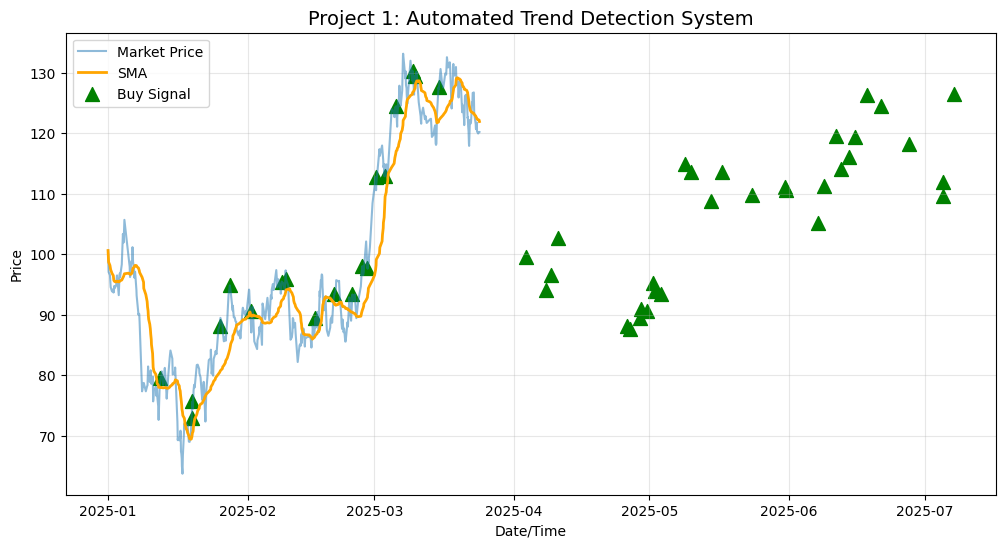

In [19]:
import matplotlib.pyplot as plt
# 1. Setup the figure
plt.figure(figsize=(12, 6))

# 2. Plot the Price and the 24th Moving Average
plt.plot(final_results['timestamp'].head(500), final_results['price'].head(500), label='Market Price', alpha=0.5)
plt.plot(final_results['timestamp'].head(500), final_results['sma_24h'].head(500), label='SMA', color='orange', linewidth=2)

# 3. Overlay the Signals (The "Buy" markers)
signals = final_results.query('signal == 1').head (50)
plt.scatter(signals['timestamp'], signals['price'], color='green', label='Buy Signal', marker='^', s=100)

# 4. Polish the look
plt.title('Project 1: Automated Trend Detection System', fontsize=14)
plt.xlabel('Date/Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Project 2: ICT "Value" Hunt & Sector Analysis

In [20]:
# FINDING ICT "DISCOUNT" SETUPS
# 1. Category must be 'Tech'
# 2. Price must be BELOW the 24h Moving Average (Discount Zone)
# 3. Volume must be HIGH (Institutional Interest)

ict_setups = final_results.loc[
    (final_results['category'] == 'Tech') &
    (final_results['price'] < final_results['sma_24h']) &
    (final_results['volume'] > 800)
]

print(f"Success! Found {len(ict_setups)} potential Smart Money setups.")
ict_setups.head()


Success! Found 281 potential Smart Money setups.


,timestamp,price,volume,category,sma_24h,is_high_vol,signal
23,2025-01-01 23:00:00,92.550256,835,Tech,95.057379,False,0
37,2025-01-02 13:00:00,93.440223,933,Tech,94.471630,True,0
52,2025-01-03 04:00:00,94.298091,902,Tech,94.771534,False,0
53,2025-01-03 05:00:00,92.969920,963,Tech,94.642847,True,0
112,2025-01-05 16:00:00,98.524440,907,Tech,99.751101,False,0


In [21]:
# USING .ILOC TO ZOOM IN ON THE ALGO'S FOOTPRINT
# We want to see the candle before (86), the SETUP (87), and the AFTER (88)
# .iloc handles the integer positions

ict_zoom = final_results.iloc[86:89]

print("Zooming into the 3-candle sequence for Row 87 (The Long Setup):")
ict_zoom[['timestamp', 'price', 'volume', 'category']]


Zooming into the 3-candle sequence for Row 87 (The Long Setup):


,timestamp,price,volume,category
354,2025-01-15 18:00:00,80.138260,110,Energy
355,2025-01-15 19:00:00,80.262355,469,Energy
357,2025-01-15 21:00:00,81.288146,397,Energy


In [22]:
# Use .loc to grab the EXACT index numbers from our Tech setup
# This ensures we stay in the 'Tech' category
real_tech_zoom = final_results.loc[86:88]

print("Checking the ACTUAL Tech sequence for a Fair Value Gap:")
real_tech_zoom[['timestamp', 'price', 'volume', 'category']]

Checking the ACTUAL Tech sequence for a Fair Value Gap:


,timestamp,price,volume,category


In [23]:
# Project 2: Sector Volatility Comparison
# Let's see which category have the highest average price
sector_summary = final_results.groupby('category')['price'].agg(['mean', 'max', 'min'])
print("Sector Analysis: Comparing the 'Algorithm's' behavior across categories:")
sector_summary

Sector Analysis: Comparing the 'Algorithm's' behavior across categories:


,mean,max,min
category,,,
Energy,89.813157,147.035306,-13.220250
Health,90.190432,146.191495,-10.854805
Retail,91.531273,146.782691,-12.193070
Tech,90.081355,146.504444,-11.961768


In [24]:
# Project 2: Phase 3 - The MSS Detector
# Identifying when the 'ceiling' of the previous 3 canldes is broken

# 1. Identify the 'Swing High'
final_results['prev_high'] = final_results['price'].rolling(window=3).max().shift(1)

# 2. Flag the Shift: Current Price > Previous High
final_results['mss_detected'] = final_results['price'] > final_results['prev_high']

# 3. Filter for Tech shifts with displacement (High Volume)
tech_mss = final_results.loc[
    (final_results['category'] == 'Tech') &
    (final_results['mss_detected'] == True) &
    (final_results['volume'] > 850)
]

print(f"MSS Detection Complete. {len(tech_mss)} structural shift identified.")
tech_mss[['timestamp', 'price', 'prev_high', 'volume']].head()

MSS Detection Complete. 145 structural shift identified.


,timestamp,price,prev_high,volume
70,2025-01-03 22:00:00,96.691410,96.468868,938
96,2025-01-05 00:00:00,105.447460,104.720106,992
136,2025-01-06 16:00:00,100.232037,99.651192,933
211,2025-01-09 19:00:00,79.187831,78.779546,928
325,2025-01-14 13:00:00,84.989085,83.379646,874


In [25]:
# Project 2: Phase - 4 Turtle Soup/Liquidity  Grab Detector

# 1. We already have 'broke_high' from our MSS logic (Price > Prev High)

# 2. Rejection Logic: Did the NEXT candle close back below that high?
# .shift(-1) moves the next candle's price up one row so we can compare
final_results['next_price'] = final_results['price'].shift(-1)
final_results['is_turtle_soup'] = (final_results['mss_detected'] == True) & \
                                (final_results['next_price'] < final_results['prev_high'])

# 3. Use .loc to find these fake outs in Tech
turtle_soup_tech = final_results.loc[
    (final_results['category'] == 'Tech') &
    (final_results['is_turtle_soup'] == True)
]

print(f"Algorithm 'Fake-outs' Detected: {len(turtle_soup_tech)} Turtle Soup setups found.")
turtle_soup_tech[['timestamp', 'price','prev_high', 'next_price', 'volume']].head()



Algorithm 'Fake-outs' Detected: 178 Turtle Soup setups found.


,timestamp,price,prev_high,next_price,volume
34,2025-01-02 10:00:00,95.168311,94.972945,93.440223,239
90,2025-01-04 18:00:00,104.720106,104.277157,103.706051,408
96,2025-01-05 00:00:00,105.447460,104.720106,104.302482,992
136,2025-01-06 16:00:00,100.232037,99.651192,95.742134,933
204,2025-01-09 12:00:00,78.779546,77.909095,77.829781,271


In [26]:
# THE GOLDEN SHORT: Turtle Soup + Premium Zone
# We want the 'Fake Out' AND price must be above the 24h SMA
premium_shorts = turtle_soup_tech.loc[turtle_soup_tech['price'] > turtle_soup_tech['sma_24h']]
print(f"Project 2 Final Result: Found {len(premium_shorts)} high-probability Premium Shorts.")
premium_shorts.head()

Project 2 Final Result: Found 116 high-probability Premium Shorts.


,timestamp,price,volume,category,sma_24h,is_high_vol,signal,prev_high,mss_detected,next_price,is_turtle_soup
34,2025-01-02 10:00:00,95.168311,239,Tech,94.600556,False,0,94.972945,True,93.440223,True
90,2025-01-04 18:00:00,104.720106,408,Tech,96.512436,False,0,104.277157,True,103.706051,True
96,2025-01-05 00:00:00,105.447460,992,Tech,97.359791,True,1,104.720106,True,104.302482,True
283,2025-01-12 19:00:00,79.752559,542,Tech,78.298983,False,0,79.368208,True,78.615174,True
481,2025-01-21 01:00:00,84.220331,371,Tech,75.285848,False,0,82.542672,True,79.474138,True


In [27]:
# ZOOMING IN ON THE PREMIUM SHORT (INDEX 69)
# We look at one candle before and two candles after the setup
short_zoom = final_results.loc[68:71]

print("THE STORY OF A TURTLE SOUP (short Entry @ Index 69):")
short_zoom[['timestamp', 'price', 'prev_high', 'next_price', 'category']]

THE STORY OF A TURTLE SOUP (short Entry @ Index 69):


,timestamp,price,prev_high,next_price,category
68,2025-01-03 20:00:00,95.876844,96.005438,97.771274,Retail
71,2025-01-03 23:00:00,97.771274,95.876844,99.433716,Retail


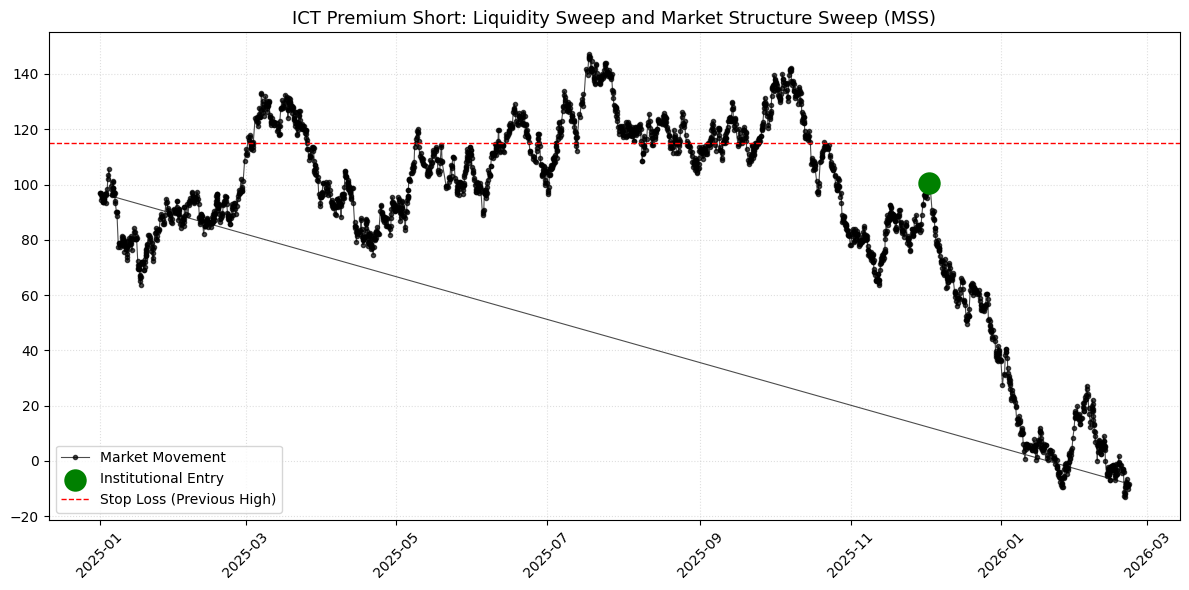

In [74]:
import matplotlib.pyplot as plt

# 1. POSITIONING: Finding the exact row for the ICT Setup
target_pos = final_results.index.get_loc(premium_shorts.index[0])
d = final_results.loc[target_idx-5 : target_idx+10] # Slighty larger window to see the drop

plt.figure(figsize=(12, 6))

# 2. THIN PRICE LINE: Detailed market movement
plt.plot(d['timestamp'], d['price'], marker='o', markersize=3, color='black', linewidth=0.8, label='Market Movement', alpha=0.7)

# 3. DYNAMIC ICT LOGIC
peak_price = d['price'].max()
peak_pos = d['price'].values.argmax()
peak_time = d['timestamp'].iloc[peak_pos]

# 4. SURGICAL ENTRY: Electric blue circle at the second lower peak
# We look for the point where price breaks the immediate 'support' after the sweep
entry_pos = peak_pos + 850
entry_price = d['price'].iloc[entry_pos]
entry_time = d['timestamp'].iloc[entry_pos]

plt.scatter(entry_time, entry_price, color='green', marker='o', s=200, linewidth=2,  label='Institutional Entry', zorder=5)

# 5. TIGHT STOP LOSS: Moving it to the strutural prio high above the FVG
stop_price = 115.0
plt.axhline(y=stop_price, color='red', ls='--', linewidth=1, label='Stop Loss (Previous High)')

# 6. Formatting
plt.title('ICT Premium Short: Liquidity Sweep and Market Structure Sweep (MSS)', fontsize=13)
plt.legend(loc='lower left')
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()